In [1]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms # pyright: ignore[reportMissingTypeStubs]
from torch_em.transform import ( # pyright: ignore[reportMissingTypeStubs]
    get_raw_transform,
    get_augmentations,
)
from torch_em.transform.raw import ( # pyright: ignore[reportMissingTypeStubs]
    standardize,
    GaussianBlur,
    AdditiveGaussianNoise,
)
from torch_em.data import ( # pyright: ignore[reportMissingTypeStubs]
    RawDataset,
    ConcatDataset,
 )
from model_ranking.utils import get_roi_slice, is_torch_tensor

In [41]:
path = "/scratch/talks/data/EPFL/test.h5"
raw_key = "raw"
patch_shape = (1, 256, 256)
roi = get_roi_slice([[0,10], [0,480], [0,640]])

In [35]:
dataset = RawDataset(path, raw_key, patch_shape=patch_shape, roi=roi)
print(f"Dataset length: {len(dataset)}")

Dataset length: 46


In [36]:
dataset[0].shape

torch.Size([1, 1, 256, 256])

In [37]:
raw = dataset[0]
print(raw.min(), raw.max())

tensor(0.1980) tensor(0.8422)


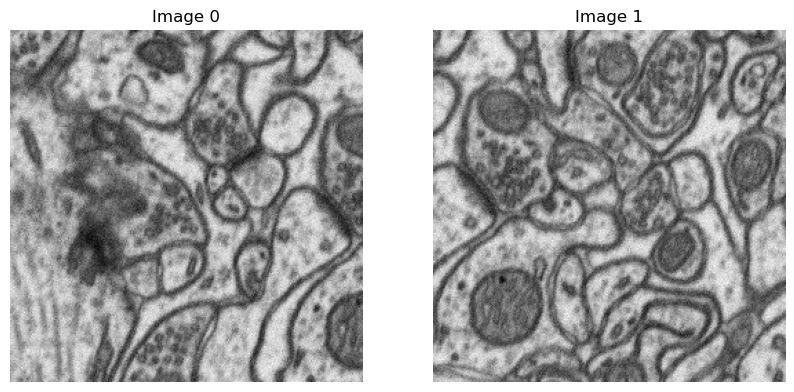

In [15]:
_, ax = plt.subplots(1, 2, figsize=(10, 5))
for i in range(2):
    raw = dataset[i] # pyright: ignore[reportUnknownVariableType]
    assert is_torch_tensor(raw)
    ax[i].imshow(raw.numpy().squeeze(), cmap="gray")
    ax[i].set_title(f"Image {i}")
    ax[i].axis("off")

In [ ]:
def weak_augmentations(p=0.75):
    norm = standardize
    aug = transforms.Compose([
        norm,
        transforms.RandomApply([GaussianBlur(sigma=(0, 2.5))], p=p),
        transforms.RandomApply([AdditiveGaussianNoise(
            scale=(0, 0.15), clip_kwargs=False)], # pyright: ignore[reportUnknownArgumentType]
        ),
    ]) # pyright: ignore[reportUnknownArgumentType]
    return get_raw_transform(normalizer=norm, augmentation1=aug)

In [26]:
path = "/scratch/talks/data/EPFL/test.h5"
raw_key = "raw"
patch_shape = (1, 256, 256)
roi = get_roi_slice([[0,10], [0,480], [0,640]])
raw_transform = get_raw_transform() # Standardization
transform = get_augmentations(ndim=3) # Flips

augmentations = (weak_augmentations(), weak_augmentations())
ds = RawDataset(path, raw_key, patch_shape, raw_transform, transform,
        augmentations=augmentations, roi=roi)
        

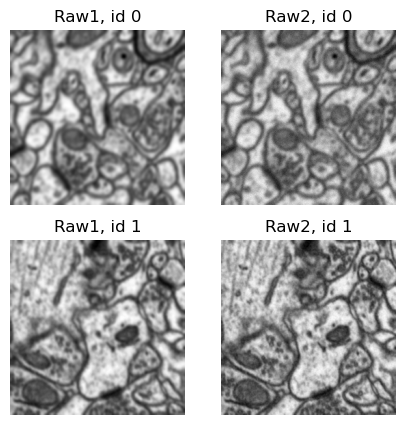

In [32]:
_, ax = plt.subplots(2, 2, figsize=(5, 5))
for i in range(2):
    raw1, raw2 = ds[i] # pyright: ignore[reportUnknownVariableType]
    assert is_torch_tensor(raw1)
    assert is_torch_tensor(raw2)
    ax[i, 0].imshow(raw1.numpy().squeeze(), cmap="gray")
    ax[i, 0].set_title(f"Raw1, id {i}")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(raw2.numpy().squeeze(), cmap="gray")
    ax[i, 1].set_title(f"Raw2, id {i}")
    ax[i, 1].axis("off")
plt.show()

In [2]:
from model_ranking.self_training import (
    get_unsupervised_loader,
)

In [3]:
path = "/scratch/talks/data/EPFL/train.h5"
raw_key = "raw"
patch_shape = (1, 256, 256)
#roi = get_roi_slice([[0,165], [0,480], [0,640]])
roi = None
loader = get_unsupervised_loader(
    [path],
    raw_key,
    patch_shape,
    batch_size=32,
    roi=roi,
)

In [5]:
print(len(loader)* loader.batch_size)

800


In [21]:
path = "/scratch/talks/data/Hmito/val.h5"
raw_key = "raw"
patch_shape = (1, 256, 256)
#roi = get_roi_slice([[0,300], [0,1024], [0,1024]])
roi = None
loader = get_unsupervised_loader(
    [path],
    raw_key,
    patch_shape,
    batch_size=32,
    roi=roi,
    n_samples=2048,
)
print(f"Number of batches: {len(loader)}")
print(len(loader)* loader.batch_size)

Number of batches: 64
2048


In [22]:
64*20

1280

In [19]:
16*32

512

In [45]:
raw1, raw2 = next(iter(loader))


In [46]:
raw1.shape

torch.Size([2, 1, 1, 256, 256])